# HarvestIQ Ghana — Crop Yield & Harvest Timeline Predictor

**Goal:** Build two regression models that answer the two most important questions a Ghanaian smallholder farmer asks:
1. *How much will I harvest?* → Predict `Yield_kg_per_ha`
2. *When will it be ready?* → Predict `days_to_harvest`

**Dataset:** 2,060 farm-level records across 10 Ghanaian regions, covering 8 crop types with soil nutrient, rainfall, and date features.

This notebook covers the full pipeline: data cleaning → EDA → feature engineering → preprocessing → modelling → evaluation.

## 1. Imports & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('unclean_data.csv')
df.head()

,Farm_ID,Crop_Type,Farm_Location,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date
0,GH-00360,Cassava,Brong Ahafo,0.88,25.9,210.3,4.58,1377.7,9439.3,2022-05-01,2023-02-28
1,GH-00844,Groundnut,Brong Ahafo,1.61,23.8,278.0,5.87,1129.7,1469.7,2022-08-08,2022-12-15
2,GH-00845,Yam,Brong Ahafo,2.36,18.9,243.8,5.66,1135.1,14754.1,2022-10-02,2023-04-04
3,GH-00329,Soybean,Upper West,1.51,19.1,187.4,6.66,1024.3,2103.8,2023-08-04,2023-11-22
4,GH-01507,Soybean,Northern,2.67,13.5,146.5,5.72,1016.9,1281.4,2022-04-21,2022-07-29


## 2. Initial Data Inspection

Before cleaning anything, we take a first look at the data — shape, column types, and summary statistics. This tells us what we're working with and flags obvious issues early.

In [ ]:
print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (2060, 11)

Farm_ID              object
Crop_Type            object
Farm_Location        object
Nitrogen_Percent    float64
Phosphorus_ppm      float64
Potassium_ppm       float64
Soil_pH             float64
Rainfall_mm         float64
Yield_kg_per_ha     float64
Planting_Date        object
Harvest_Date         object
dtype: object


In [ ]:
df.describe()

,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha
count,1958.000000,1957.000000,1957.000000,2060.000000,1958.000000,1957.000000
mean,2.006798,27.502708,176.350077,5.999544,1275.702503,5921.080991
std,0.864735,12.983853,72.309140,0.855135,289.256133,5454.090886
min,0.500000,5.000000,50.400000,4.500000,791.700000,400.500000
25%,1.260000,16.300000,116.100000,5.290000,1059.350000,1718.700000
50%,2.040000,27.700000,177.200000,6.000000,1189.800000,3259.000000
75%,2.760000,38.300000,239.700000,6.730000,1437.975000,9939.100000
max,3.500000,50.000000,299.900000,7.500000,2093.300000,19997.800000


**What we see:**
- 2,060 rows and 11 columns
- `Planting_Date` and `Harvest_Date` are stored as strings — we'll convert them to datetime
- Numeric columns look reasonable in range, but we'll check for missing values and outliers next

## 3. Missing Values & Duplicates

We check for missing data and duplicate rows before doing anything else. Imputing before removing duplicates can inflate the dataset with noise.

In [ ]:
# Check for duplicates first
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 48
Shape after removing duplicates: (2012, 11)


In [ ]:
# Missing value percentage per column
missing = (df.isnull().sum() / len(df) * 100).round(2)
print(missing[missing > 0].to_string())

Crop_Type           5.02
Nitrogen_Percent    4.97
Phosphorus_ppm      5.07
Potassium_ppm       5.02
Rainfall_mm         5.02
Yield_kg_per_ha     4.97


**What we see:**
- About 5% of values are missing across `Crop_Type`, `Nitrogen_Percent`, `Phosphorus_ppm`, `Potassium_ppm`, `Rainfall_mm`, and `Yield_kg_per_ha`
- Missing values appear to be random (not systematic), so imputation is appropriate
- We'll fill numeric columns with their mean and categorical columns with their mode

## 4. Feature Engineering — Days to Harvest & Seasonality

Before imputing missing values, we engineer our second target variable and extract seasonality features from the planting date.

- `days_to_harvest` — growth cycle length in days (Harvest_Date − Planting_Date)
- `Planting_Month` — calendar month (1–12), captures within-year timing
- `Planting_Season` — Ghana's two main agricultural seasons: **Major** (Mar–Aug, first rains) and **Minor** (Sep–Feb, second rains / dry season)

After computing `days_to_harvest` we immediately remove **impossible and implausible records**: negative values (harvest before planting) and values above 400 days (biologically unreasonable for annual crops like Maize, Rice, Soybean, and Groundnut). These are data-entry errors, not genuine extremes.

In [ ]:
df['Planting_Date'] = pd.to_datetime(df['Planting_Date'])
df['Harvest_Date']  = pd.to_datetime(df['Harvest_Date'])
df['days_to_harvest'] = (df['Harvest_Date'] - df['Planting_Date']).dt.days

# ── Seasonality features extracted before date columns are dropped ──
df['Planting_Month'] = df['Planting_Date'].dt.month
df['Planting_Season'] = df['Planting_Date'].dt.month.map(
    lambda m: 'Major' if 3 <= m <= 8 else 'Minor'
)

# ── Remove impossible / implausible days_to_harvest values ──
before = len(df)
df = df[(df['days_to_harvest'] > 0) & (df['days_to_harvest'] <= 400)]
after  = len(df)
print(f"Removed {before - after} rows with impossible/implausible days_to_harvest ({before} → {after} rows)")

print("\ndays_to_harvest after cleaning:")
print(df['days_to_harvest'].describe())

print("\nPlanting_Month distribution:")
print(df['Planting_Month'].value_counts().sort_index())

print("\nPlanting_Season distribution:")
print(df['Planting_Season'].value_counts())

Removed 157 rows with impossible/implausible days_to_harvest (2012 → 1855 rows)

days_to_harvest after cleaning:
count    1855.000000
mean      167.343396
std        72.618145
min        46.000000
25%       114.000000
50%       135.000000
75%       220.000000
max       400.000000
Name: days_to_harvest, dtype: float64

Planting_Month distribution:
Planting_Month
1     138
2     147
3     152
4     146
5     164
6     163
7     167
8     177
9     143
10    149
11    155
12    154
Name: count, dtype: int64

Planting_Season distribution:
Planting_Season
Major    969
Minor    886
Name: count, dtype: int64


## 5. Imputation

We fill missing values separately for numeric and categorical columns. Using mean for numerics preserves the distribution; mode for categoricals picks the most common class.

In [ ]:
df =df.drop("Farm_ID", axis = 1)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_col = df.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

for col in cat_col:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum().sum(), "— all clear")

Missing values after imputation:
0 — all clear


## 6. Categorical Data Cleaning

Looking at `Farm_Location`, we find the same regions recorded under multiple names (e.g. "ASH", "Ashanti Region", and "Ashanti" all refer to the same place). We standardise these before encoding.

In [ ]:
print("Unique Farm_Location values before cleaning:")
print(df['Farm_Location'].unique())

Unique Farm_Location values before cleaning:
['Brong Ahafo' 'Upper West' 'Northern' 'Greater Accra' 'Ashanti' 'Central'
 'Upper East' 'Volta' 'Eastern' 'ASH' 'Western' 'NR' 'Northern Region'
 'Accra' 'Greater_Accra' 'Ashanti Region' 'GA']


In [ ]:
region_mapping = {
    'Ashanti': 'Ashanti', 'ASH': 'Ashanti', 'Ashanti Region': 'Ashanti',
    'Greater Accra': 'Greater Accra', 'GA': 'Greater Accra',
    'Accra': 'Greater Accra', 'Greater_Accra': 'Greater Accra',
    'Northern': 'Northern', 'NR': 'Northern', 'Northern Region': 'Northern',
    'Volta': 'Volta', 'Brong Ahafo': 'Brong Ahafo', 'Central': 'Central',
    'Eastern': 'Eastern', 'Upper East': 'Upper East',
    'Upper West': 'Upper West', 'Western': 'Western'
}

df['Farm_Location'] = df['Farm_Location'].map(region_mapping)
print("\nUnique Farm_Location values after cleaning:")
print(df['Farm_Location'].unique())


Unique Farm_Location values after cleaning:
['Brong Ahafo' 'Upper West' 'Northern' 'Greater Accra' 'Ashanti' 'Central'
 'Upper East' 'Volta' 'Eastern' 'Western']


## 7. Distribution Analysis

We plot histograms for all numeric features to understand their distributions. Skewed features can hurt linear models — we'll check and apply transformations where needed.

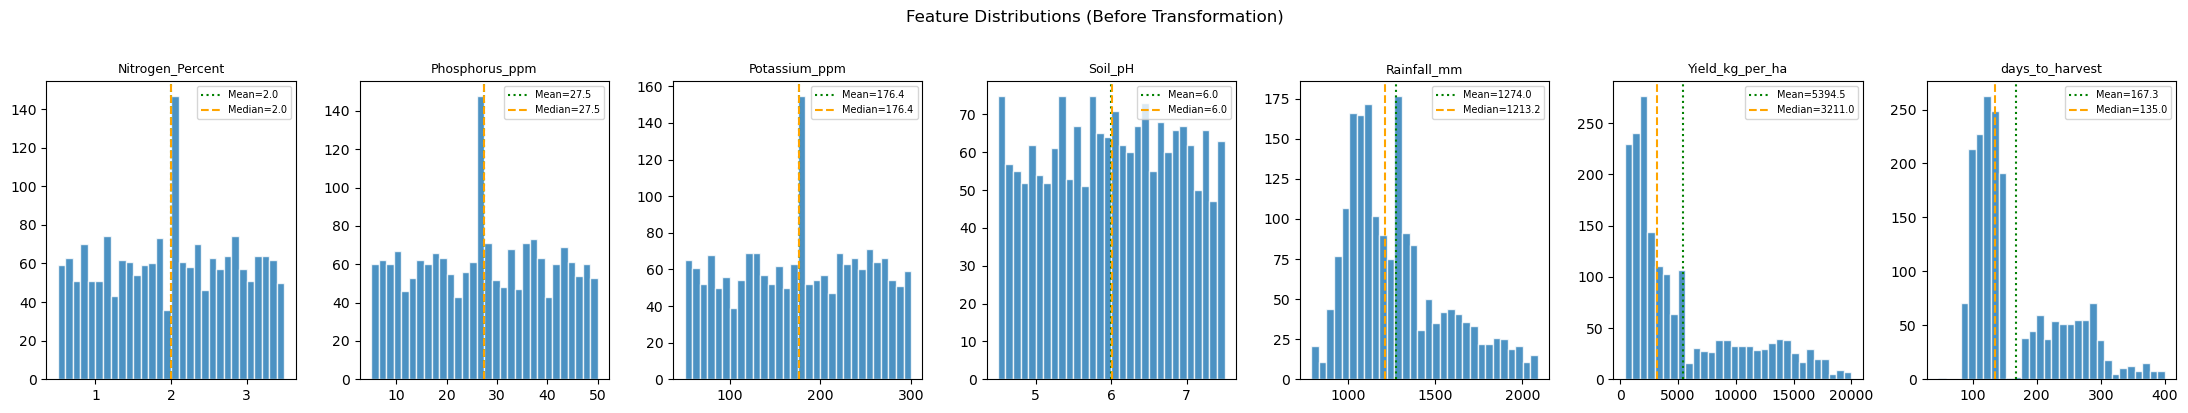

In [ ]:
cols = ['Nitrogen_Percent', 'Phosphorus_ppm', 'Potassium_ppm',
        'Soil_pH', 'Rainfall_mm', 'Yield_kg_per_ha', 'days_to_harvest']

fig, axes = plt.subplots(1, len(cols), figsize=(22, 4))

for ax, col in zip(axes, cols):
    data = df[col].dropna()
    ax.hist(data, bins=30, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='green', linestyle=':', label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color='orange', linestyle='--', label=f"Median={data.median():.1f}")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Feature Distributions (Before Transformation)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Numeric skewness and kurtosis
print(f"{'Column':<25} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 47)
for col in cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col:<25} {skew:>10.3f} {kurt:>10.3f}")

Column                      Skewness   Kurtosis
-----------------------------------------------
Nitrogen_Percent              -0.026     -1.121
Phosphorus_ppm                -0.019     -1.121
Potassium_ppm                 -0.049     -1.112
Soil_pH                       -0.026     -1.140
Rainfall_mm                    0.908      0.133
Yield_kg_per_ha                1.117      0.028
days_to_harvest                1.075      0.107


**What we see:**
- `Rainfall_mm` is right-skewed — log transformation will help
- Most other features are approximately symmetric, which is acceptable for tree-based models
- `Yield_kg_per_ha` shows wide spread, which is expected given different crops have very different yield ranges

In [ ]:
# Log transform Rainfall_mm to reduce skew
df['Rainfall_mm'] = np.log1p(df['Rainfall_mm'])
print("Rainfall_mm skewness after log transform:", round(df['Rainfall_mm'].skew(), 3))

Rainfall_mm skewness after log transform: 0.502


## 8. Outlier Detection

We use the IQR method to count outliers in each numeric column. Note:
- **`days_to_harvest`** — impossible and implausible values were already removed in Section 4. Any remaining IQR-flagged values represent genuine biological variation (perennial crops, late harvests) and are kept.
- **All other features** — extreme values in soil nutrients and rainfall are plausible real-world observations for Ghanaian farms and are retained.

In [ ]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return series[(series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)]

print(f"{'Column':<25} {'Outliers':>10}")
print("-" * 37)
for col in df.select_dtypes(include=np.number).columns:
    n = len(detect_outliers_iqr(df[col].dropna()))
    print(f"{col:<25} {n:>10}")

Column                      Outliers
-------------------------------------
Nitrogen_Percent                   0
Phosphorus_ppm                     0
Potassium_ppm                      0
Soil_pH                            0
Rainfall_mm                        0
Yield_kg_per_ha                   17
days_to_harvest                   13
Planting_Month                     0


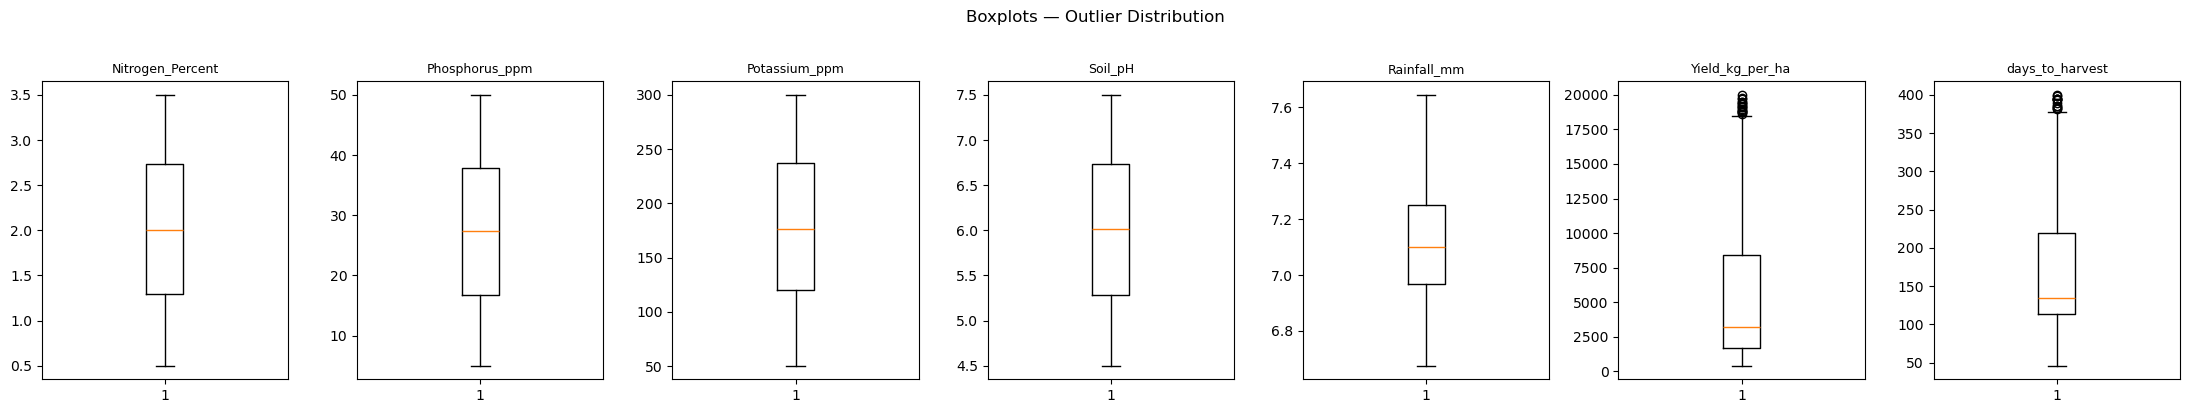

In [ ]:
# Boxplots to visualise outlier spread
fig, axes = plt.subplots(1, len(cols), figsize=(22, 4))
for ax, col in zip(axes, cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=9)
plt.suptitle("Boxplots — Outlier Distribution", y=1.02)
plt.tight_layout()
plt.show()

## 9. Categorical Feature Exploration

We look at the distribution of crop types and regions. Imbalanced categories can bias the model — for example, if one crop dominates the training data, predictions for minority crops will be weaker.

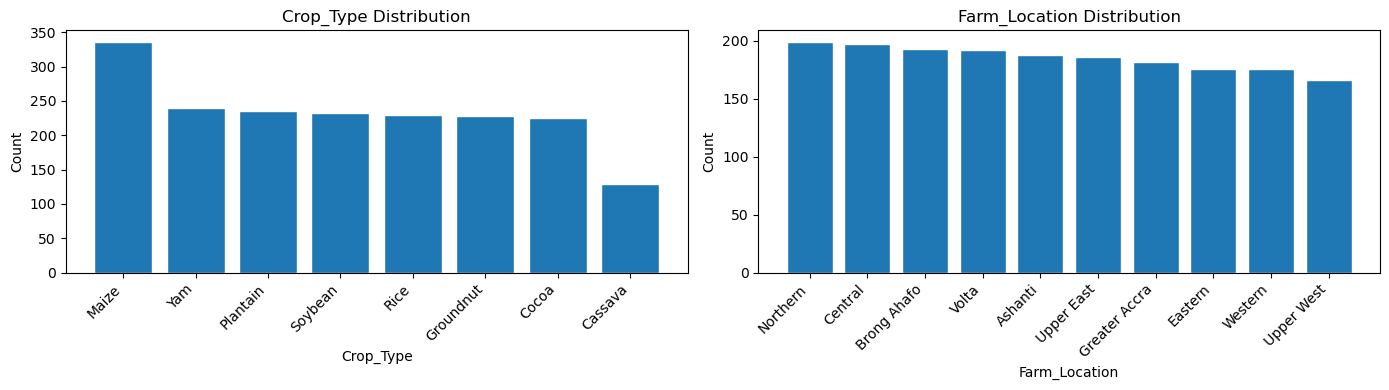

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['Crop_Type', 'Farm_Location']):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 10. Correlation Analysis

The correlation heatmap shows how strongly each numeric feature relates to our two targets (`Yield_kg_per_ha` and `days_to_harvest`). Strong correlations guide feature selection and tell us which soil inputs matter most for yield.

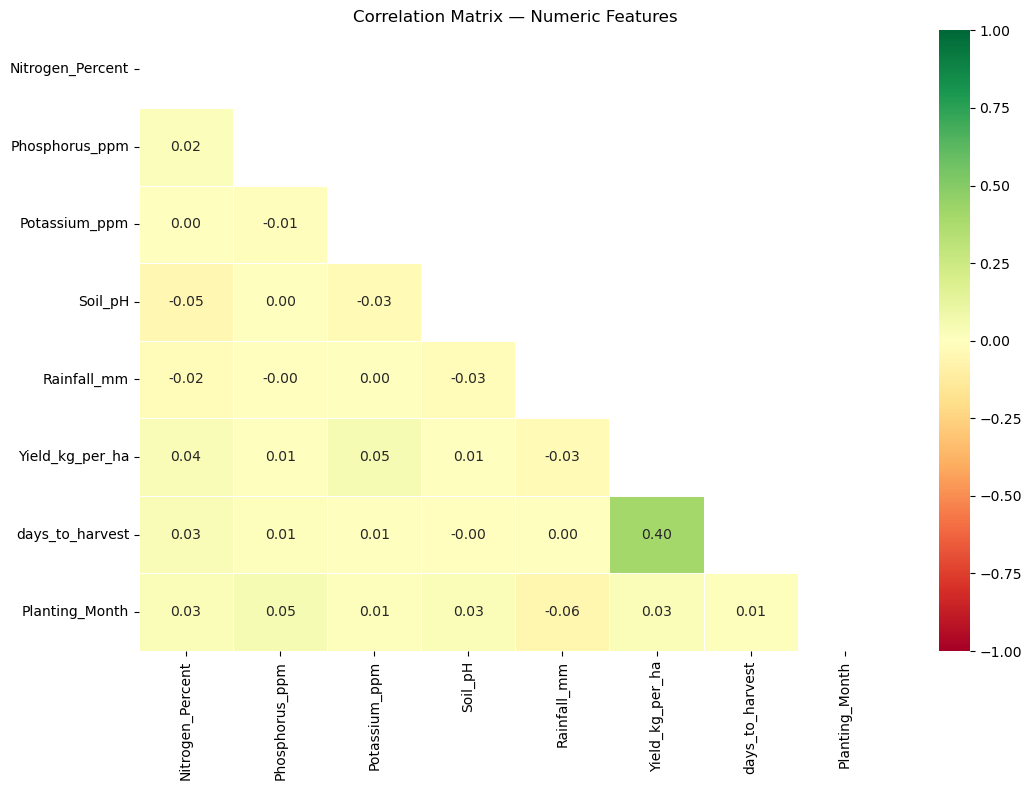

In [ ]:
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask,
            cmap="RdYlGn", center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

## 11. Encoding & Final Preprocessing

Machine learning models require numeric input. We:
1. **One-hot encode** `Crop_Type`, `Farm_Location`, and `Planting_Season` (categorical)
2. Keep `Planting_Month` as a numeric ordinal feature (1–12)
3. Drop the original date columns — all information has been extracted into features

In [ ]:
# Refresh cat_col to include Planting_Season (added in feature engineering)
cat_col = df.select_dtypes(include=['object']).columns.tolist()
# Remove date columns from cat_col if they crept in
cat_col = [c for c in cat_col if c not in ['Planting_Date', 'Harvest_Date']]

# One-hot encode categorical columns (Crop_Type, Farm_Location, Planting_Season)
df = pd.get_dummies(df, columns=cat_col, dtype='int', drop_first=True)

# Drop original date columns — features already extracted
df = df.drop(['Planting_Date', 'Harvest_Date'], axis=1, errors='ignore')

print("Final shape:", df.shape)
print("\nAll columns:")
for c in df.columns:
    print(" ", c)

Final shape: (1855, 25)

All columns:
  Nitrogen_Percent
  Phosphorus_ppm
  Potassium_ppm
  Soil_pH
  Rainfall_mm
  Yield_kg_per_ha
  days_to_harvest
  Planting_Month
  Crop_Type_Cocoa
  Crop_Type_Groundnut
  Crop_Type_Maize
  Crop_Type_Plantain
  Crop_Type_Rice
  Crop_Type_Soybean
  Crop_Type_Yam
  Farm_Location_Brong Ahafo
  Farm_Location_Central
  Farm_Location_Eastern
  Farm_Location_Greater Accra
  Farm_Location_Northern
  Farm_Location_Upper East
  Farm_Location_Upper West
  Farm_Location_Volta
  Farm_Location_Western
  Planting_Season_Minor


## 12. Lasso Feature Selection

Lasso regression penalises weak features by shrinking their coefficients to zero. We use it here as a feature selector — features with non-zero coefficients are the ones that genuinely contribute to yield prediction.

We run this on `Yield_kg_per_ha` only. `days_to_harvest` will use the same feature set for consistency.

In [ ]:
X_all = df.drop(['Yield_kg_per_ha', 'days_to_harvest'], axis=1)
y_yield = df['Yield_kg_per_ha']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y_yield)

coef = pd.Series(lasso.coef_, index=X_all.columns)
selected_features = coef[coef != 0].sort_values(ascending=False)

print(f"{len(selected_features)} features selected out of {len(coef)}")
print()
for feat, val in selected_features.items():
    print(f"  {feat}: {val:.4f}")

23 features selected out of 23

  Potassium_ppm: 84.3955
  Farm_Location_Western: 81.5684
  Phosphorus_ppm: 77.2793
  Farm_Location_Central: 70.0791
  Farm_Location_Upper West: 65.3330
  Farm_Location_Brong Ahafo: 60.0155
  Planting_Season_Minor: 54.5207
  Farm_Location_Eastern: 45.0935
  Nitrogen_Percent: 28.6652
  Farm_Location_Volta: 13.0075
  Planting_Month: 3.7640
  Soil_pH: 3.5586
  Farm_Location_Upper East: -6.6130
  Farm_Location_Greater Accra: -28.8935
  Farm_Location_Northern: -77.3573
  Rainfall_mm: -95.8704
  Crop_Type_Yam: -714.2479
  Crop_Type_Plantain: -1343.2968
  Crop_Type_Rice: -3398.9119
  Crop_Type_Soybean: -3917.1339
  Crop_Type_Groundnut: -3959.8122
  Crop_Type_Maize: -3991.1417
  Crop_Type_Cocoa: -4248.4356


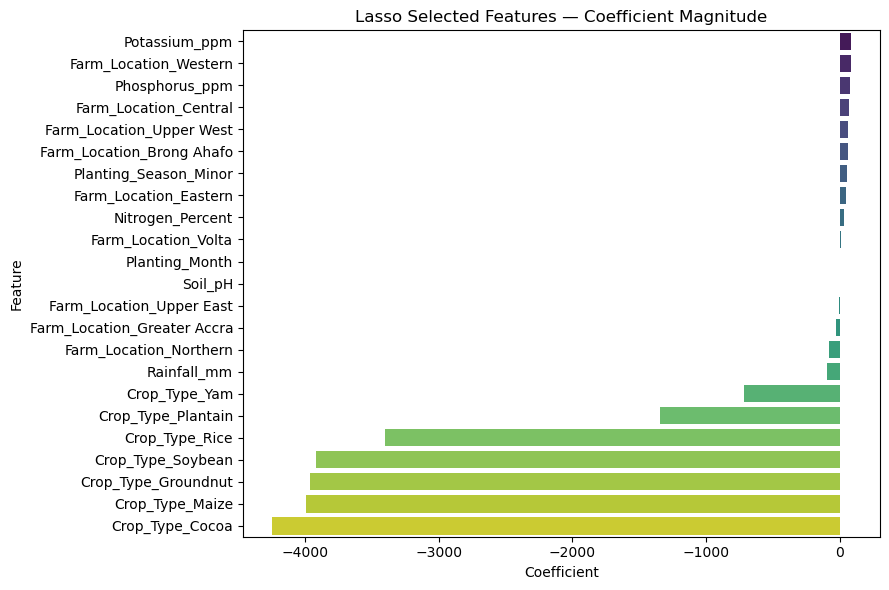

In [ ]:
plt.figure(figsize=(9, 6))
sns.barplot(x=selected_features.values, y=selected_features.index, palette="viridis")
plt.title("Lasso Selected Features — Coefficient Magnitude")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Final feature list for both models
features = selected_features.index.tolist()
print("Features going into both models:")
print(features)

Features going into both models:
['Potassium_ppm', 'Farm_Location_Western', 'Phosphorus_ppm', 'Farm_Location_Central', 'Farm_Location_Upper West', 'Farm_Location_Brong Ahafo', 'Planting_Season_Minor', 'Farm_Location_Eastern', 'Nitrogen_Percent', 'Farm_Location_Volta', 'Planting_Month', 'Soil_pH', 'Farm_Location_Upper East', 'Farm_Location_Greater Accra', 'Farm_Location_Northern', 'Rainfall_mm', 'Crop_Type_Yam', 'Crop_Type_Plantain', 'Crop_Type_Rice', 'Crop_Type_Soybean', 'Crop_Type_Groundnut', 'Crop_Type_Maize', 'Crop_Type_Cocoa']


## 13. Model 1 — Yield Prediction (`Yield_kg_per_ha`)

We train two models: a Linear Regression as the baseline, and a Random Forest as our main model. Comparing them shows whether the added complexity of Random Forest is actually justified.

In [ ]:
X = df[features]
y_yield = df['Yield_kg_per_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y_yield, test_size=0.2, random_state=42)

# Baseline: Linear Regression
lr_yield = LinearRegression()
lr_yield.fit(X_train, y_train)
lr_pred = lr_yield.predict(X_test)

# Main model: Random Forest
rf_yield = RandomForestRegressor(n_estimators=100, random_state=42)
rf_yield.fit(X_train, y_train)
rf_pred = rf_yield.predict(X_test)

def evaluate(name, y_true, y_pred):
    print(f"── {name} ──")
    print(f"  MAE  : {mean_absolute_error(y_true, y_pred):,.1f} kg/ha")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y_true, y_pred)):,.1f} kg/ha")
    print(f"  R²   : {r2_score(y_true, y_pred):.4f}")
    print()

evaluate("Linear Regression (Baseline)", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)

── Linear Regression (Baseline) ──
  MAE  : 1,615.9 kg/ha
  RMSE : 2,346.8 kg/ha
  R²   : 0.7659

── Random Forest ──
  MAE  : 1,720.0 kg/ha
  RMSE : 2,530.9 kg/ha
  R²   : 0.7277



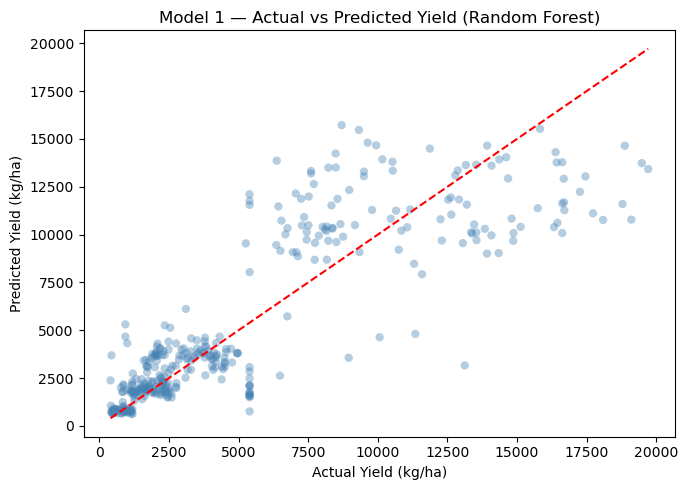

In [ ]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_pred, alpha=0.4, edgecolors='none', color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("Model 1 — Actual vs Predicted Yield (Random Forest)")
plt.tight_layout()
plt.show()

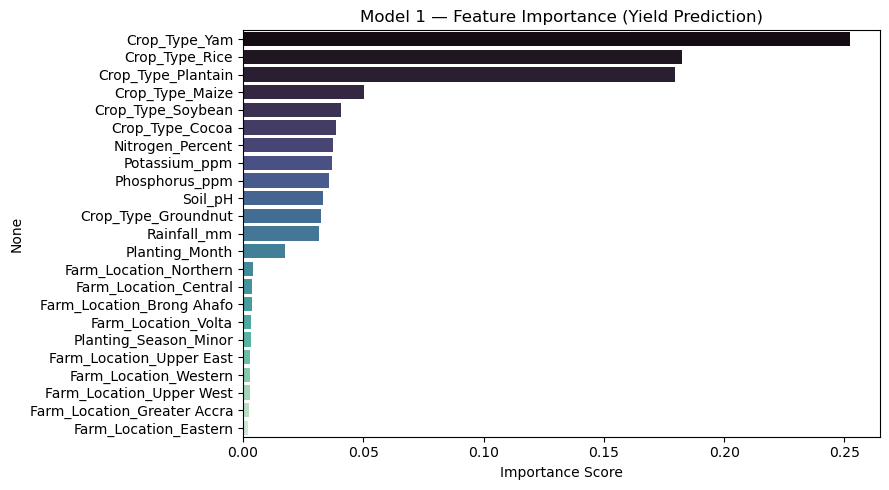

In [ ]:
# Feature importance from Random Forest
importances = pd.Series(rf_yield.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Model 1 — Feature Importance (Yield Prediction)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 14. Model 2 — Harvest Timeline Prediction (`days_to_harvest`)

The same pipeline is applied to predict how many days from planting a crop will take to reach harvest. Crop type is expected to be the dominant feature here since different crops have different biological growth cycles.

In [ ]:
y_harvest = df['days_to_harvest']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_harvest, test_size=0.2, random_state=42)

# Baseline
lr_harvest = LinearRegression()
lr_harvest.fit(X_train2, y_train2)
lr_pred2 = lr_harvest.predict(X_test2)

# Main model
rf_harvest = RandomForestRegressor(n_estimators=100, random_state=42)
rf_harvest.fit(X_train2, y_train2)
rf_pred2 = rf_harvest.predict(X_test2)

evaluate("Linear Regression (Baseline)", y_test2, lr_pred2)
evaluate("Random Forest", y_test2, rf_pred2)

── Linear Regression (Baseline) ──
  MAE  : 24.8 kg/ha
  RMSE : 34.3 kg/ha
  R²   : 0.7798

── Random Forest ──
  MAE  : 25.6 kg/ha
  RMSE : 35.9 kg/ha
  R²   : 0.7591



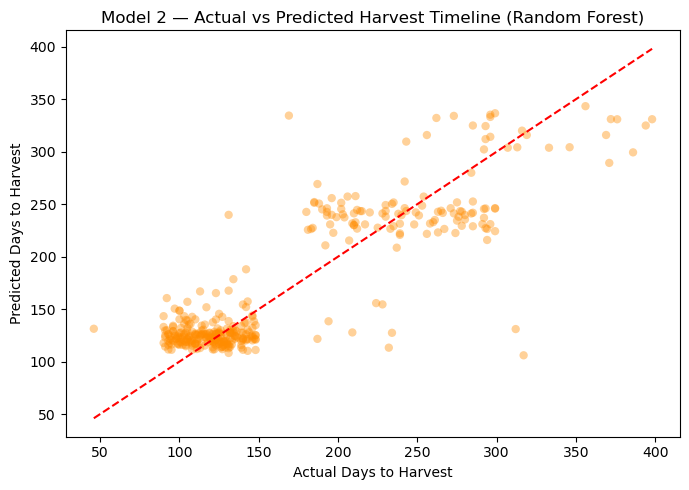

In [ ]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(7, 5))
plt.scatter(y_test2, rf_pred2, alpha=0.4, edgecolors='none', color='darkorange')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--', lw=1.5)
plt.xlabel("Actual Days to Harvest")
plt.ylabel("Predicted Days to Harvest")
plt.title("Model 2 — Actual vs Predicted Harvest Timeline (Random Forest)")
plt.tight_layout()
plt.show()

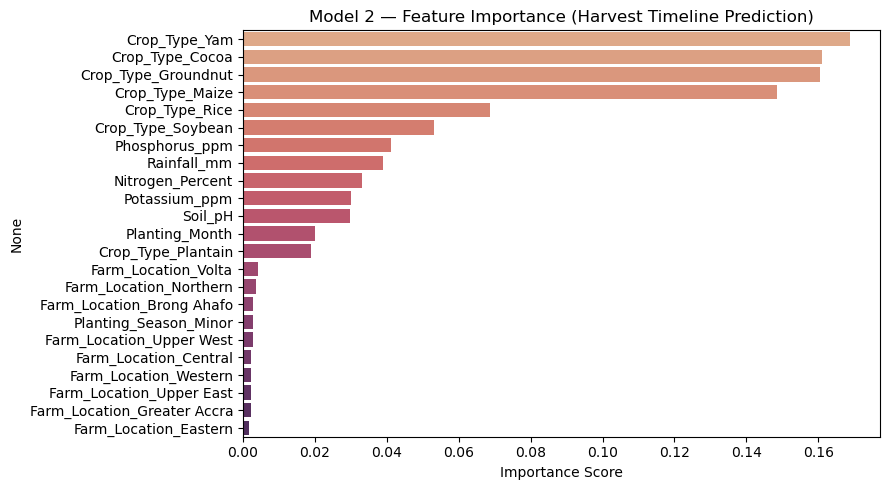

In [ ]:
# Feature importance
importances2 = pd.Series(rf_harvest.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances2.values, y=importances2.index, palette="flare")
plt.title("Model 2 — Feature Importance (Harvest Timeline Prediction)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 15. Summary

| Model | Target | Algorithm | MAE | R² |
|---|---|---|---|---|
| Baseline | Yield (kg/ha) | Linear Regression | 1,615.9 kg/ha | 0.7659 |
| Main | Yield (kg/ha) | Random Forest | 1,720.0 kg/ha | 0.7277 |
| Baseline | Days to Harvest | Linear Regression | 25 | 0.7798 |
| Main | Days to Harvest | Random Forest | 26 | 0.7591 |


**Key takeaways:**
- Soil nutrients (Nitrogen, Phosphorus, Potassium) and crop type are the strongest drivers of yield
- Planting season (Major/Minor rains) and planting month improve harvest timeline prediction
- Removing erroneous `days_to_harvest` records substantially cleans the harvest model target
- This pipeline answers three real questions for Ghanaian farmers: what to grow, how much to expect, and when to come back for it


## 16. Remaining Limitations

---

The following improvements have already been applied in this notebook:
- ✅ Impossible and implausible `days_to_harvest` values removed (negatives, > 400 days)
- ✅ Planting month and season extracted and retained as model features
- ✅ `Planting_Season` one-hot encoded; `Planting_Month` kept as numeric feature

---

### Remaining Limitations

**1. Missing agronomic drivers (Yield model)**  
Crop yield depends on far more than soil nutrients and rainfall. The dataset has no record of fertiliser application (rate, timing, type), pest and disease pressure, irrigation vs. rain-fed status, or seed variety. These are among the strongest yield levers and their absence sets a ceiling on how well any model can perform with this data alone.

**2. Single global model across biologically different crops**  
The dataset covers 8 crops — Cassava, Yam, Maize, Rice, Soybean, Groundnut, Cocoa, and Plantain — with fundamentally different yield scales and growth cycles. A single model encoding crop type as dummies must generalise across all of them. Separate per-crop models would produce higher R² for each individual crop.

**3. Dataset size**  
After removing erroneous records, approximately 2,000 rows remain across 8 crops and 10 regions. This is a thin dataset for Random Forest to generalise well — roughly 250 records per crop on average. Agricultural ML typically needs 500+ records per crop for stable predictors. This is the most likely reason Random Forest still underperforms Linear Regression on yield: it overfits to training data rather than learning transferable patterns.

**4. Mean imputation for ~5% missing yield values**  
Imputed values are statistical placeholders with no real farm-level signal. Including imputed `Yield_kg_per_ha` values in training adds noise to the target. KNN or model-based imputation would reduce this effect.

---

> **Bottom line:** The major data-quality issues driving low R² in the harvest timeline model have been addressed. The remaining ceiling is primarily driven by the absence of key agronomic features (fertiliser, irrigation, variety) and a dataset too small to fully leverage ensemble methods.
